In [1]:
from pathlib import Path
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
DATA_DIR = Path("../data/raw/chest_xray")

TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="training",
    seed=SEED
)

Found 5216 files belonging to 2 classes.
Using 4173 files for training.


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="binary",
    color_mode="rgb",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.20,
    subset="validation",
    seed=SEED
)

Found 5216 files belonging to 2 classes.
Using 1043 files for validation.


JPEG
 ↓

Load
 ↓

Resize → 224×224
 ↓

Convert grayscale → RGB
 ↓
 
Create batches

In [5]:
print("Classes:", train_ds.class_names)

Classes: ['NORMAL', 'PNEUMONIA']


In [6]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32, 1)


Phase 2.2 — Data Augmentation.

In [7]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(
        height_factor=0.05,
        width_factor=0.05
    ),
    tf.keras.layers.RandomContrast(0.10)
], name="data_augmentation")

print("Data augmentation pipeline created.")

Data augmentation pipeline created.


This phase gives us:-
Original X-ray
      ↓
Random rotation
      ↓
Random zoom
      ↓
Small translation
      ↓
Small contrast variation

VISUALIZE ARGUMENTATION

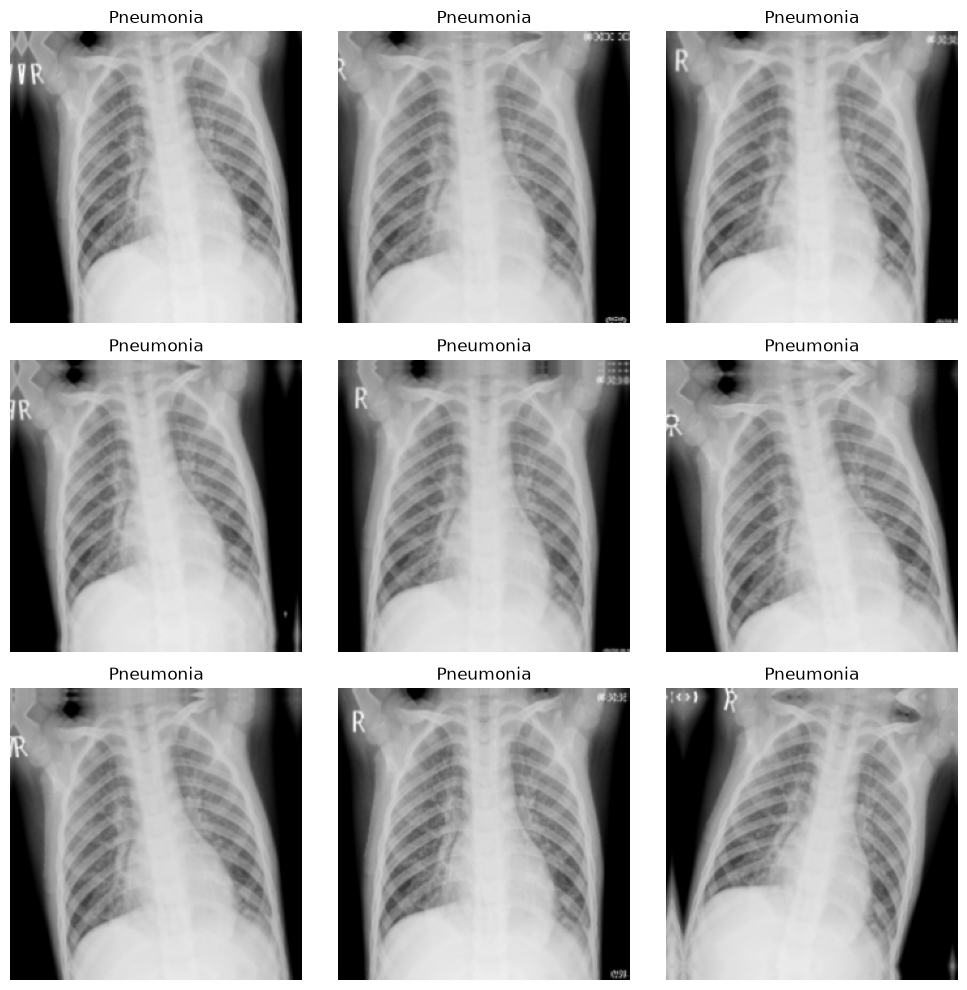

In [8]:
import matplotlib.pyplot as plt

for images, labels in train_ds.take(1):
    sample_image = images[0]
    sample_label = labels[0]

plt.figure(figsize=(10, 10))

for i in range(9):
    augmented_image = data_augmentation(
        tf.expand_dims(sample_image, 0),
        training=True
    )[0]

    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(augmented_image.numpy().astype("uint8"))
    plt.title(
        "Pneumonia" if sample_label.numpy()[0] == 1 else "Normal"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

CHECKING PIXEL VALUES

In [9]:
for images, labels in train_ds.take(1):
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 255.0


Step 4 — Optimize the dataset pipeline

In [10]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
val_ds = val_ds.prefetch(AUTOTUNE)

print("Dataset pipeline optimized.")


Dataset pipeline optimized.


Phase 3 — Handle class imbalance

In [11]:
import numpy as np

normal_count = 1341
pneumonia_count = 3875
total_count = normal_count + pneumonia_count

class_weight = {
    0: total_count / (2 * normal_count),
    1: total_count / (2 * pneumonia_count)
}

print("Class weights:")
print("NORMAL:", class_weight[0])
print("PNEUMONIA:", class_weight[1])

Class weights:
NORMAL: 1.9448173005219984
PNEUMONIA: 0.6730322580645162
